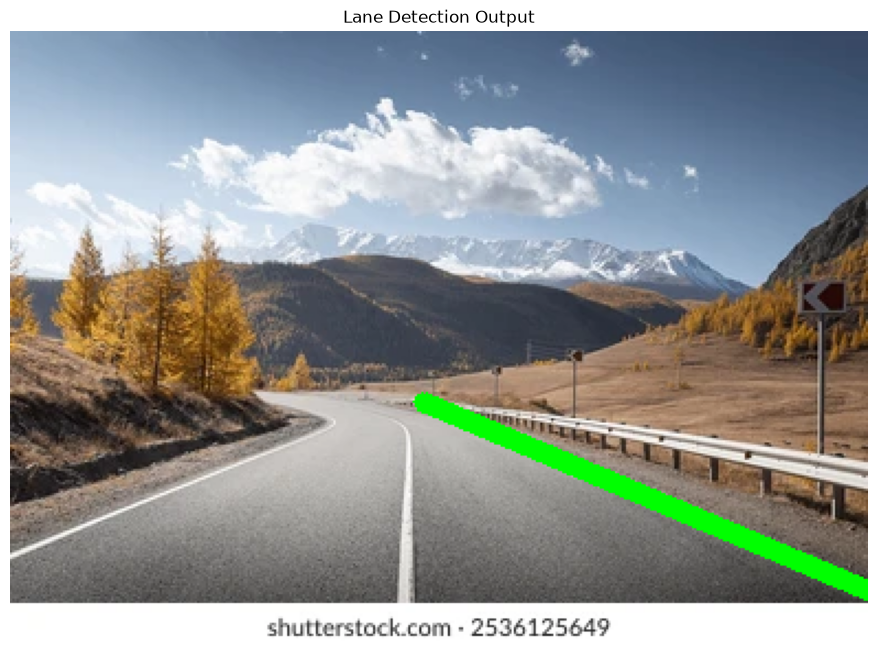

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread("road.webp")
if image is None:
    raise FileNotFoundError("road.jpg not found")

output = image.copy()
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blur, 50, 150)
h, w = edges.shape
mask = np.zeros_like(edges)

polygon = np.array([[
    (0, h),
    (w, h),
    (int(0.58 * w), int(0.58 * h)),
    (int(0.42 * w), int(0.58 * h))
]], dtype=np.int32)

cv2.fillPoly(mask, polygon, 255)
roi_edges = cv2.bitwise_and(edges, mask)

# HOUGH TRANSFORM

lines = cv2.HoughLinesP(
    roi_edges,
    rho=1,
    theta=np.pi / 180,
    threshold=30,
    minLineLength=30,
    maxLineGap=100
)

left_lines = []
right_lines = []

if lines is not None:

    # Makes line format consistently:
    # [x1, y1, x2, y2]
    lines = lines.reshape(-1, 4)

    for x1, y1, x2, y2 in lines:

        # Avoid division by zero
        if x2 == x1:
            continue

        # Calculate slope
        slope = (y2 - y1) / (x2 - x1)

        # Negative slope = left lane
        if -1.5 < slope < -0.4:
            left_lines.append((x1, y1, x2, y2))

        # Positive slope = right lane
        elif 0.4 < slope < 1.5:
            right_lines.append((x1, y1, x2, y2))

def average_line(lines, y_bottom, y_top):

    if len(lines) == 0:
        return None

    xs = []
    ys = []

    for x1, y1, x2, y2 in lines:
        xs.extend([x1, x2])
        ys.extend([y1, y2])

    # Fit line: y = slope*x + intercept
    slope, intercept = np.polyfit(xs, ys, 1)

    if abs(slope) < 1e-6:
        return None

    x_bottom = int((y_bottom - intercept) / slope)
    x_top = int((y_top - intercept) / slope)

    return x_bottom, y_bottom, x_top, y_top

y_bottom = h - 1
y_top = int(0.60 * h)

left_lane = average_line(left_lines, y_bottom, y_top)
right_lane = average_line(right_lines, y_bottom, y_top)

if left_lane is not None:
    x1, y1, x2, y2 = left_lane
    cv2.line(output, (x1, y1), (x2, y2), (0, 255, 0), 8)

if right_lane is not None:
    x1, y1, x2, y2 = right_lane
    cv2.line(output, (x1, y1), (x2, y2), (0, 255, 0), 8)

output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(output_rgb)
plt.title("Lane Detection Output")
plt.axis("off")
plt.show()